# Preparación del dataset en PyTorch -- Detección de Patrones de Velas Japonesas

Dataset en formato **YOLOv8**: cada imagen tiene bounding boxes con su clase.
El modelo aprenderá a localizar el patrón dentro de la imagen Y clasificarlo.

## Alcance

1. Descarga reproducible del dataset (Roboflow).
2. Preprocesamiento: eliminación del fondo blanco.
3. Splits estratificados train / val / test con semilla fija.
4. Distribución de clases por split.
5. `Dataset` personalizado de PyTorch para detección.
6. Data augmentation (solo train) + visualización del efecto.
7. `DataLoader` con `collate_fn` para detección.
8. Verificación final del batch.


## 1. Imports y configuración global

In [1]:
from pathlib import Path
import subprocess, sys

import pandas as pd
import numpy as np
import yaml
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

ROOT           = Path("..")
DATA_ROOT      = ROOT / "data"
PROCESSED_ROOT = DATA_ROOT / "processed" / "dataset_no_background"

SPLIT_CSV = {
    "train": DATA_ROOT / "train.csv",
    "valid": DATA_ROOT / "val.csv",
    "test":  DATA_ROOT / "test.csv",
}

BATCH_SIZE  = 16
NUM_WORKERS = 0   # 0 evita errores de pickling con multiprocessing en Windows + Jupyter
SEED        = 42

plt.rcParams["figure.figsize"] = (12, 8)


## 2. Descarga del dataset

Dataset de [Roboflow](https://universe.roboflow.com/madhumitha-jc-hvsdd/candlestick-pattern/dataset/1).
La descarga es idempotente: si `data/raw/` ya existe, no se vuelve a bajar.

In [2]:
RAW_DATASET     = DATA_ROOT / "raw"
DOWNLOAD_SCRIPT = ROOT / "dowload_dataset.py"


def raw_dataset_is_ready(raw_root: Path) -> bool:
    required = [raw_root / "train", raw_root / "valid",
                raw_root / "test",  raw_root / "data.yaml"]
    return all(p.exists() for p in required)


if raw_dataset_is_ready(RAW_DATASET):
    print(f"Dataset ya existe en: {RAW_DATASET.resolve()}")
else:
    if not DOWNLOAD_SCRIPT.exists():
        raise FileNotFoundError(f"No se encontró el script: {DOWNLOAD_SCRIPT.resolve()}")
    print("Descargando dataset...")
    subprocess.run([sys.executable, str(DOWNLOAD_SCRIPT)], check=True)
    print(f"Descarga finalizada en: {RAW_DATASET.resolve()}")


Dataset ya existe en: C:\Users\viche\Desktop\redes neuronales\Reconocimiento-Patrones-velas-Japonesas\data\raw


## 3. Eliminación del fondo + generación de splits

**Fondo:** flood fill desde las esquinas (siempre blancas) + morfología para suavizar bordes.
Guardamos RGBA con canal alpha: 0 = fondo, 255 = vela.

**Splits 70/20/10:** estratificados por clase con seed=42 -> misma partición en cualquier máquina.

In [3]:
import cv2, shutil, random
from tqdm import tqdm

PROCESSED_DATASET = PROCESSED_ROOT
WHITE_THRESHOLD   = 240
MORPH_KERNEL_SIZE = 3
VALID_EXTENSIONS  = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".webp"}
TRAIN_RATIO       = 0.7
VAL_RATIO         = 0.2
TEST_RATIO        = 0.1
REGENERATE_SPLITS = True


def remove_white_background(img_bgr: np.ndarray, threshold=WHITE_THRESHOLD,
                            kernel_size=MORPH_KERNEL_SIZE) -> np.ndarray:
    h, w      = img_bgr.shape[:2]
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    white_mask = (np.all(img_rgb >= threshold, axis=2).astype(np.uint8) * 255)

    flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    flood_img  = white_mask.copy()
    for fy, fx in [(0,0), (0,w-1), (h-1,0), (h-1,w-1)]:
        if white_mask[fy, fx] == 255:
            cv2.floodFill(flood_img, flood_mask, (fx, fy), 128,
                          loDiff=10, upDiff=10, flags=cv2.FLOODFILL_FIXED_RANGE)

    bg_mask = (flood_img == 128).astype(np.uint8) * 255
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    bg_mask = cv2.morphologyEx(bg_mask, cv2.MORPH_CLOSE, kernel)
    bg_mask = cv2.morphologyEx(bg_mask, cv2.MORPH_DILATE, kernel)

    alpha = cv2.bitwise_not(bg_mask)
    alpha = cv2.GaussianBlur(alpha, (3, 3), 0)
    _, alpha = cv2.threshold(alpha, 10, 255, cv2.THRESH_BINARY)

    b, g, r = cv2.split(img_bgr)
    return cv2.merge([b, g, r, alpha])


def _discover_image_label_dirs(root: Path):
    if (root / "images").exists() and (root / "labels").exists():
        return root / "images", root / "labels"
    for child in root.iterdir():
        if child.is_dir() and (child/"images").exists() and (child/"labels").exists():
            return child / "images", child / "labels"
    for p in root.rglob("images"):
        if (p.parent / "labels").exists():
            return p, p.parent / "labels"
    return None, None


def create_stratified_splits(raw_dataset: Path, seed=SEED, train_ratio=TRAIN_RATIO,
                              val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, force=False):
    random.seed(seed)

    existing_splits = [d for d in ["train","valid","test"] if (raw_dataset/d).exists()]
    all_items = []
    if existing_splits:
        for s in existing_splits:
            img_dir = raw_dataset / s / "images"
            lbl_dir = raw_dataset / s / "labels"
            if img_dir.exists() and lbl_dir.exists():
                for p in sorted(img_dir.iterdir()):
                    if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
                        all_items.append((p, lbl_dir / f"{p.stem}.txt"))
    else:
        img_dir, lbl_dir = _discover_image_label_dirs(raw_dataset)
        if img_dir is None:
            raise FileNotFoundError(f"No se encontraron imágenes en {raw_dataset}")
        for p in sorted(img_dir.iterdir()):
            if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
                all_items.append((p, lbl_dir / f"{p.stem}.txt"))

    if not all_items:
        raise FileNotFoundError(f"No se encontraron imágenes en {raw_dataset}")

    # Movemos splits viejos a backup para evitar leer/escribir al mismo tiempo
    backup_dir = None
    if existing_splits and force:
        backup_dir = raw_dataset / "_split_source_backup"
        if backup_dir.exists(): shutil.rmtree(backup_dir)
        backup_dir.mkdir(parents=True, exist_ok=True)
        for s in existing_splits:
            (raw_dataset/s).replace(backup_dir/s)
        all_items = [(backup_dir/p.relative_to(raw_dataset),
                      backup_dir/lbl.relative_to(raw_dataset)) for p,lbl in all_items]

    records_by_class, unlabeled = {}, []
    for img, lbl in all_items:
        cls = None
        if lbl.exists():
            txt = lbl.read_text().strip()
            if txt:
                try: cls = int(txt.split()[0])
                except: pass
        if cls is None: unlabeled.append((img, lbl))
        else: records_by_class.setdefault(cls, []).append((img, lbl))

    train_items, val_items, test_items = [], [], []
    for cls, items in records_by_class.items():
        random.shuffle(items)
        n      = len(items)
        n_train = int(round(n * train_ratio))
        n_val   = min(int(round(n * val_ratio)), n - n_train)
        train_items.extend(items[:n_train])
        val_items.extend(items[n_train:n_train+n_val])
        test_items.extend(items[n_train+n_val:])

    random.shuffle(unlabeled)
    n = len(unlabeled)
    n_tr = int(round(n*train_ratio)); n_v = min(int(round(n*val_ratio)), n-n_tr)
    train_items.extend(unlabeled[:n_tr])
    val_items.extend(unlabeled[n_tr:n_tr+n_v])
    test_items.extend(unlabeled[n_tr+n_v:])

    def _write_split(name, items):
        out_img = raw_dataset / name / "images"
        out_lbl = raw_dataset / name / "labels"
        out_img.mkdir(parents=True, exist_ok=True)
        out_lbl.mkdir(parents=True, exist_ok=True)
        for ip, lp in items:
            shutil.copy2(ip, out_img / ip.name)
            if lp.exists(): shutil.copy2(lp, out_lbl / lp.name)

    print(f"Splits (seed={seed}): train={len(train_items)}, valid={len(val_items)}, test={len(test_items)}")

    for s in ["train","valid","test"]:
        sdir = raw_dataset / s
        if sdir.exists() and any(sdir.iterdir()):
            if force and backup_dir is None: shutil.rmtree(sdir)
            elif not force:
                print(f"{sdir} ya existe. Usar force=True para regenerar.")
                return

    _write_split("train", train_items)
    _write_split("valid", val_items)
    _write_split("test",  test_items)

    def _rows(items, split_name):
        return [{"image": f"{split_name}/images/{ip.stem}.png",
                 "label": f"{split_name}/labels/{ip.stem}.txt"} for ip, _ in items]
    pd.DataFrame(_rows(train_items,"train")).to_csv(DATA_ROOT/"train.csv", index=False)
    pd.DataFrame(_rows(val_items,  "valid")).to_csv(DATA_ROOT/"val.csv",   index=False)
    pd.DataFrame(_rows(test_items, "test" )).to_csv(DATA_ROOT/"test.csv",  index=False)
    print(f"CSVs guardados en {DATA_ROOT}")

    if backup_dir and backup_dir.exists():
        try: shutil.rmtree(backup_dir)
        except: pass


def process_dataset(raw_dataset: Path, processed_dataset: Path):
    if not raw_dataset.exists():
        raise FileNotFoundError(f"No existe: {raw_dataset.resolve()}")

    total = 0
    for split in ["train","valid","test"]:
        in_imgs  = raw_dataset / split / "images"
        in_lbls  = raw_dataset / split / "labels"
        out_imgs = processed_dataset / split / "images"
        out_lbls = processed_dataset / split / "labels"
        out_imgs.mkdir(parents=True, exist_ok=True)
        out_lbls.mkdir(parents=True, exist_ok=True)

        paths = [p for p in sorted(in_imgs.iterdir())
                 if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS]
        print(f"\n[{split.upper()}] {len(paths)} imágenes")

        for img_path in tqdm(paths, desc=f"Procesando {split}"):
            img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img is None: continue
            cv2.imwrite(str(out_imgs / f"{img_path.stem}.png"), remove_white_background(img))
            lbl = in_lbls / f"{img_path.stem}.txt"
            if lbl.exists(): shutil.copy2(lbl, out_lbls / lbl.name)
            total += 1

    yaml_src = raw_dataset / "data.yaml"
    if yaml_src.exists():
        processed_dataset.mkdir(parents=True, exist_ok=True)
        shutil.copy2(yaml_src, processed_dataset / "data.yaml")

    print(f"\nTotal: {total} imágenes | Salida: {processed_dataset.resolve()}")


if RAW_DATASET.exists():
    splits_missing = not all((RAW_DATASET/s).exists() for s in ["train","valid","test"])
    if splits_missing or REGENERATE_SPLITS:
        create_stratified_splits(RAW_DATASET, seed=SEED, force=REGENERATE_SPLITS)
    process_dataset(RAW_DATASET, PROCESSED_DATASET)
else:
    print(f"No existe: {RAW_DATASET.resolve()}")


Splits (seed=42): train=813, valid=232, test=115
CSVs guardados en ..\data

[TRAIN] 813 imágenes


Procesando train: 100%|██████████| 813/813 [00:08<00:00, 93.80it/s] 



[VALID] 232 imágenes


Procesando valid: 100%|██████████| 232/232 [00:02<00:00, 91.45it/s] 



[TEST] 115 imágenes


Procesando test: 100%|██████████| 115/115 [00:01<00:00, 90.83it/s]


Total: 1160 imágenes | Salida: C:\Users\viche\Desktop\redes neuronales\Reconocimiento-Patrones-velas-Japonesas\data\processed\dataset_no_background


## 4. Verificación de la estructura del dataset

In [4]:
print("Processed root:", PROCESSED_ROOT.resolve())
print("Exists:", PROCESSED_ROOT.exists())
print("\nCSV de splits:")
for split, path in SPLIT_CSV.items():
    print(f"  {split}: {path.exists()} ({path.relative_to(ROOT)})")

yaml_path = PROCESSED_ROOT / "data.yaml"
if yaml_path.exists():
    with open(yaml_path, "r", encoding="utf-8") as f:
        yaml_data = yaml.safe_load(f)
    print("\nClases:", yaml_data.get("names"))
    print("nc:", yaml_data.get("nc"))
else:
    print("data.yaml no encontrado.")
    yaml_data = {"names": [], "nc": 0}


Processed root: C:\Users\viche\Desktop\redes neuronales\Reconocimiento-Patrones-velas-Japonesas\data\processed\dataset_no_background
Exists: True

CSV de splits:
  train: True (data\train.csv)
  valid: True (data\val.csv)
  test: True (data\test.csv)

Clases: ['Bearish Engulfing', 'Bearish Insidebar', 'Bullish Engulfing', 'Bullish Insidebar', 'Hammer', 'Inverted_Hammer']
nc: 6


## 5. Distribución de clases por split

Verificamos que la estratificación funcionó: cada clase debe tener representación
proporcional en los tres splits.

In [5]:
CLASS_NAMES = yaml_data.get("names", [])
NUM_CLASSES = len(CLASS_NAMES)


def get_class_distribution(csv_path: Path, dataset_root: Path) -> dict:
    df     = pd.read_csv(csv_path)
    counts = {i: 0 for i in range(NUM_CLASSES)}
    for _, row in df.iterrows():
        lbl_path = dataset_root / row["label"]
        if lbl_path.exists():
            txt = lbl_path.read_text().strip()
            if txt:
                cls = int(txt.split()[0])
                if cls in counts:
                    counts[cls] += 1
    return counts


dist = {s: get_class_distribution(SPLIT_CSV[s], PROCESSED_ROOT) for s in ["train","valid","test"]}

distribution_df = pd.DataFrame({
    "Clase": CLASS_NAMES,
    "Train": [dist["train"][i] for i in range(NUM_CLASSES)],
    "Valid": [dist["valid"][i] for i in range(NUM_CLASSES)],
    "Test":  [dist["test"][i]  for i in range(NUM_CLASSES)],
})
distribution_df["Total"] = distribution_df[["Train","Valid","Test"]].sum(axis=1)

print(distribution_df.to_string(index=False))
print(f"\nTotales -- train: {distribution_df['Train'].sum()} | "
      f"valid: {distribution_df['Valid'].sum()} | test: {distribution_df['Test'].sum()}")


            Clase  Train  Valid  Test  Total
Bearish Engulfing     73     21    10    104
Bearish Insidebar    155     44    23    222
Bullish Engulfing    183     52    26    261
Bullish Insidebar    118     34    16    168
           Hammer    175     50    25    250
  Inverted_Hammer    105     30    15    150

Totales -- train: 809 | valid: 231 | test: 115


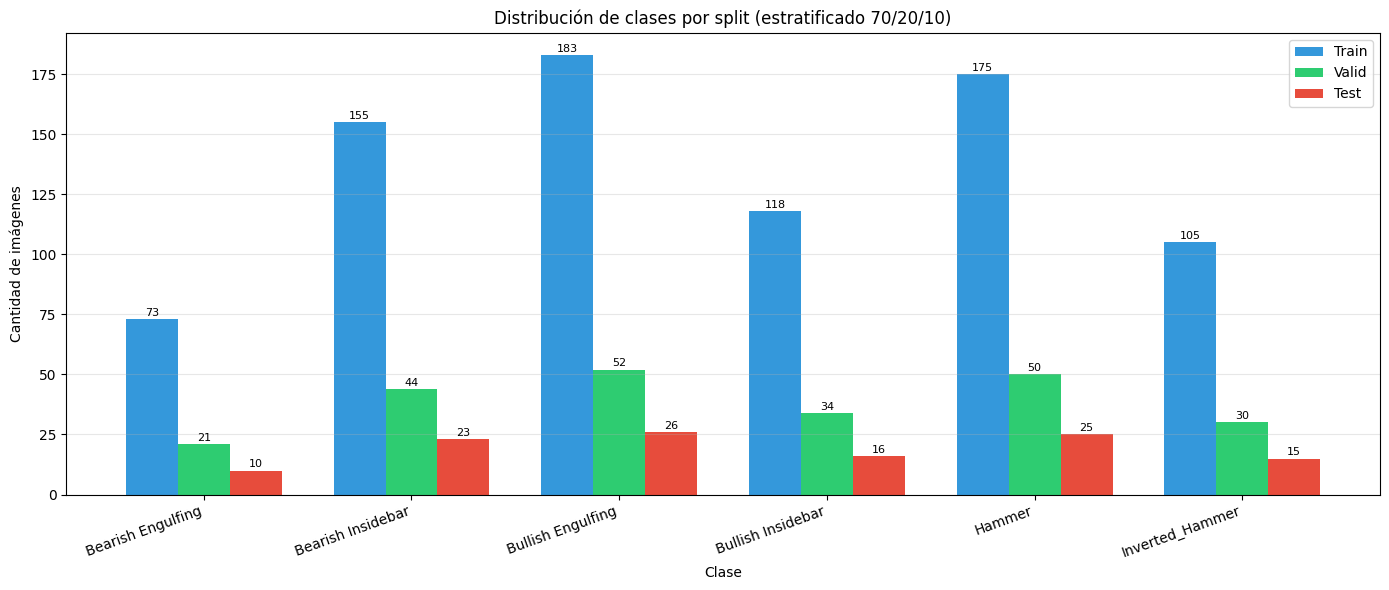

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(NUM_CLASSES)
width = 0.25

bars_train = ax.bar(x - width, distribution_df["Train"], width, label="Train", color="#3498db")
bars_valid = ax.bar(x,         distribution_df["Valid"], width, label="Valid",  color="#2ecc71")
bars_test  = ax.bar(x + width, distribution_df["Test"],  width, label="Test",   color="#e74c3c")

for bars in [bars_train, bars_valid, bars_test]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f"{int(h)}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de clases por split (estratificado 70/20/10)")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Dataset personalizado de PyTorch para detección

`__getitem__` devuelve `(imagen_tensor, target)` donde target es un dict con:
- `boxes`: tensor `[N, 4]` -- coordenadas YOLO normalizadas `(x_center, y_center, w, h)` en [0,1].
- `labels`: tensor `[N]` -- class_id de cada box.

Las coords YOLO ya están normalizadas -> no cambian al hacer resize, no hay que transformarlas.

**`collate_fn` personalizado:** necesario porque N (boxes por imagen) varía entre muestras.
Sin él el DataLoader intenta hacer `stack` de los targets y falla.

In [7]:
IMAGE_SIZE    = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def convert_to_rgb(img: Image.Image) -> Image.Image:
    # Función nombrada (no lambda) para que sea serializable por multiprocessing
    return img.convert("RGB") if img.mode != "RGB" else img


base_transforms = T.Compose([
    T.Lambda(convert_to_rgb),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ColorJitter solo en train: simula variaciones de iluminación/paleta de colores.
# NO usamos flips ni rotaciones: romperían la semántica del patrón
# (un flip horizontal puede convertir un patrón alcista en bajista).
train_transforms = T.Compose([
    T.Lambda(convert_to_rgb),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def read_yolo_annotations(label_path: Path) -> list:
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) >= 5:
            try:
                boxes.append((int(parts[0]),
                              float(parts[1]), float(parts[2]),
                              float(parts[3]), float(parts[4])))
            except ValueError:
                continue
    return boxes


class CandlestickDataset(Dataset):

    def __init__(self, csv_path: Path, dataset_root: Path, transform=None):
        self.df           = pd.read_csv(csv_path)
        self.dataset_root = dataset_root
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row        = self.df.iloc[idx]
        image_path = self.dataset_root / row["image"]
        label_path = self.dataset_root / row["label"]

        image = Image.open(image_path)
        if self.transform is not None:
            image = self.transform(image)

        annotations = read_yolo_annotations(label_path)

        if annotations:
            boxes  = torch.tensor([[x, y, w, h] for _, x, y, w, h in annotations],
                                   dtype=torch.float32)
            labels = torch.tensor([cls for cls, *_ in annotations], dtype=torch.long)
        else:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0,      dtype=torch.long)

        target = {"boxes": boxes, "labels": labels, "image_id": idx}
        return image, target

    def get_raw_sample(self, idx: int):
        # Solo para visualizacion - devuelve imagen PIL sin transformar y boxes raw
        row = self.df.iloc[idx]
        return (Image.open(self.dataset_root / row["image"]).convert("RGB"),
                read_yolo_annotations(self.dataset_root / row["label"]))


train_dataset = CandlestickDataset(SPLIT_CSV["train"], PROCESSED_ROOT, transform=train_transforms)
valid_dataset = CandlestickDataset(SPLIT_CSV["valid"], PROCESSED_ROOT, transform=base_transforms)
test_dataset  = CandlestickDataset(SPLIT_CSV["test"],  PROCESSED_ROOT, transform=base_transforms)

print(f"Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

img, target = train_dataset[0]
print(f"\nMuestra 0 -> imagen: {img.shape} | boxes: {target['boxes'].shape} | labels: {target['labels']}")


Train: 813 | Valid: 232 | Test: 115

Muestra 0 -> imagen: torch.Size([3, 224, 224]) | boxes: torch.Size([1, 4]) | labels: tensor([3])


## 7. Data augmentation -- visualización con bounding boxes

Mostramos el efecto de `ColorJitter` sobre 4 imágenes de train.
Los bounding boxes se conservan sin cambios porque las coordenadas YOLO son normalizadas.

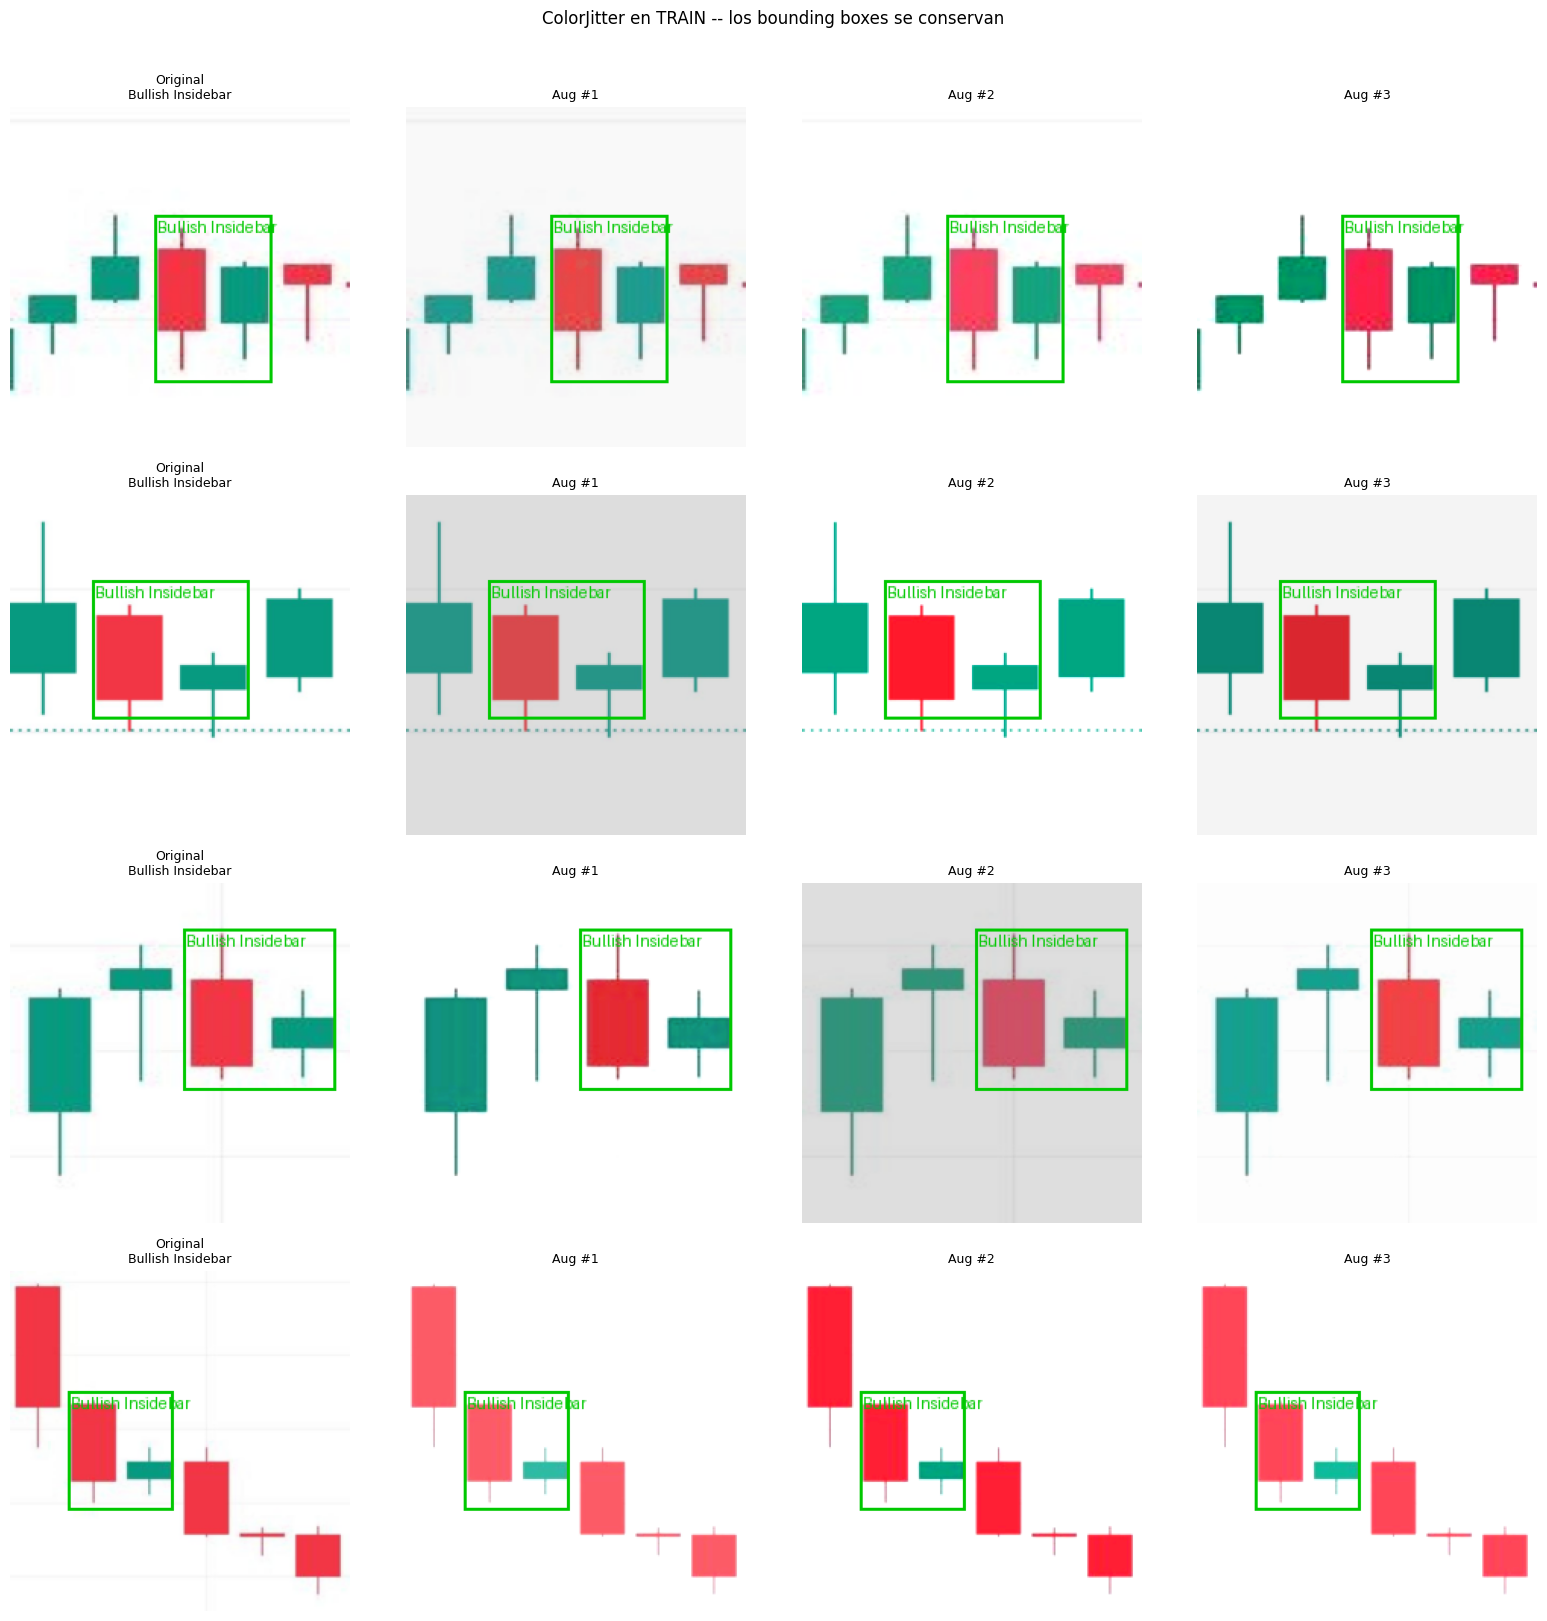

In [8]:
def draw_yolo_boxes(image_pil, boxes, class_names):
    W, H   = image_pil.size
    canvas = image_pil.copy()
    draw   = ImageDraw.Draw(canvas)
    COLORS = [(0,200,0),(200,0,0),(0,0,200),(200,200,0),(200,0,200),(0,200,200)]

    for i, (cls_id, xc, yc, bw, bh) in enumerate(boxes):
        x_min = int((xc - bw/2) * W); x_max = int((xc + bw/2) * W)
        y_min = int((yc - bh/2) * H); y_max = int((yc + bh/2) * H)
        color = COLORS[i % len(COLORS)]
        draw.rectangle([x_min, y_min, x_max, y_max], outline=color, width=2)
        label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        draw.text((x_min + 2, y_min + 2), label, fill=color)
    return canvas


aug_viz  = T.Compose([T.Lambda(convert_to_rgb), T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                      T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02)])
base_viz = T.Compose([T.Lambda(convert_to_rgb), T.Resize((IMAGE_SIZE, IMAGE_SIZE))])

NUM_IMGS_AUG = 4
AUGS_PER_IMG = 3

fig, axes = plt.subplots(NUM_IMGS_AUG, AUGS_PER_IMG + 1,
                          figsize=(4 * (AUGS_PER_IMG + 1), 4 * NUM_IMGS_AUG))
if NUM_IMGS_AUG == 1:
    axes = np.expand_dims(axes, 0)

for row_idx in range(NUM_IMGS_AUG):
    img_pil, boxes = train_dataset.get_raw_sample(row_idx)
    cls_name = CLASS_NAMES[boxes[0][0]] if boxes else "?"

    axes[row_idx, 0].imshow(draw_yolo_boxes(base_viz(img_pil), boxes, CLASS_NAMES))
    axes[row_idx, 0].set_title(f"Original\n{cls_name}", fontsize=9)
    axes[row_idx, 0].axis("off")

    for aug_idx in range(AUGS_PER_IMG):
        axes[row_idx, aug_idx+1].imshow(draw_yolo_boxes(aug_viz(img_pil), boxes, CLASS_NAMES))
        axes[row_idx, aug_idx+1].set_title(f"Aug #{aug_idx+1}", fontsize=9)
        axes[row_idx, aug_idx+1].axis("off")

plt.suptitle("ColorJitter en TRAIN -- los bounding boxes se conservan", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 8. DataLoaders

`collate_fn` personalizado: apila las imágenes en un tensor `[B, C, H, W]` y devuelve
los targets como lista de dicts (sin apilar), ya que cada imagen puede tener distinto N de boxes.

In [9]:
def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images, dim=0), list(targets)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)

images, targets = next(iter(train_loader))

print(f"images shape: {images.shape}")
print(f"targets: lista de {len(targets)} dicts")
print(f"\nEjemplo target[0]:")
print(f"  boxes  -> {targets[0]['boxes']}")
print(f"  labels -> {targets[0]['labels']}")
print(f"\nRango de valores (tras normalización): min={images.min():.4f}, max={images.max():.4f}")


images shape: torch.Size([16, 3, 224, 224])
targets: lista de 16 dicts

Ejemplo target[0]:
  boxes  -> tensor([[0.7891, 0.4914, 0.3648, 0.9078]])
  labels -> tensor([1])

Rango de valores (tras normalización): min=-2.1179, max=2.6400


## 9. Verificación final del batch

Primeras 8 imágenes del batch desnormalizadas con sus bounding boxes dibujados.
Confirma que los pares imagen-target están correctamente alineados.

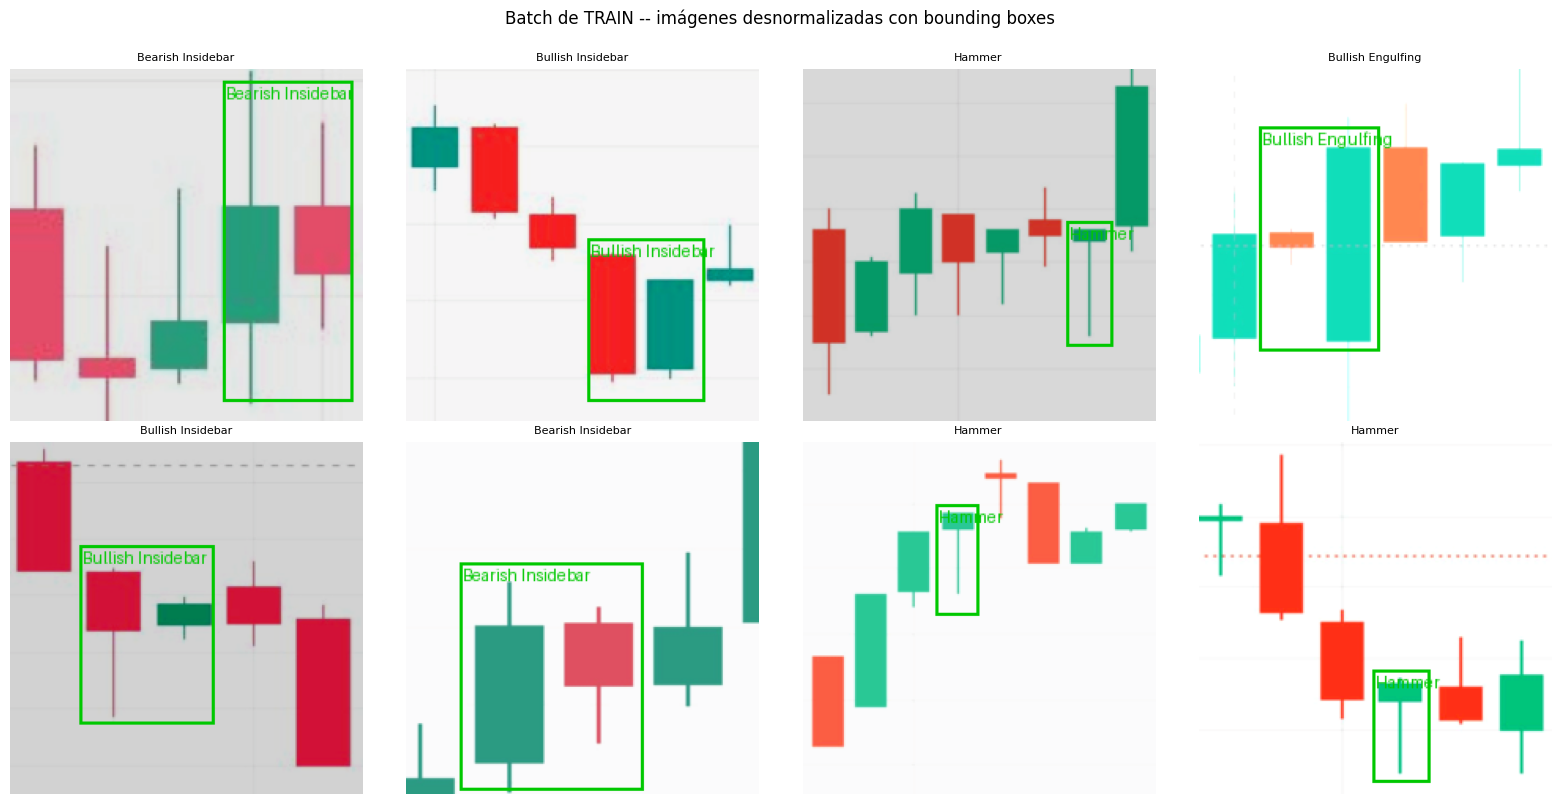


Tensor imágenes: torch.Size([16, 3, 224, 224])  dtype=torch.float32
target[0] -> 1 box(es) | labels=[1]
target[1] -> 1 box(es) | labels=[3]
target[2] -> 1 box(es) | labels=[4]
target[3] -> 1 box(es) | labels=[2]


In [10]:
# Desnormalizar: x = x_norm * std + mean  ->  Normalize con mean=-m/s, std=1/s
unnormalize = T.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

N_SHOW    = min(8, len(images))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes      = axes.flatten()

for i in range(N_SHOW):
    img_np = np.clip(unnormalize(images[i]).permute(1, 2, 0).numpy(), 0, 1)
    img_pil = Image.fromarray((img_np * 255).astype(np.uint8))

    t = targets[i]
    boxes_raw = [(int(t["labels"][j]),
                  float(t["boxes"][j][0]), float(t["boxes"][j][1]),
                  float(t["boxes"][j][2]), float(t["boxes"][j][3]))
                 for j in range(len(t["labels"]))]

    axes[i].imshow(draw_yolo_boxes(img_pil, boxes_raw, CLASS_NAMES))
    cls_names = [CLASS_NAMES[b[0]] for b in boxes_raw if b[0] < len(CLASS_NAMES)]
    axes[i].set_title(", ".join(cls_names) if cls_names else "sin label", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Batch de TRAIN -- imágenes desnormalizadas con bounding boxes", fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

print(f"\nTensor imágenes: {images.shape}  dtype={images.dtype}")
for i in range(min(4, len(targets))):
    t = targets[i]
    print(f"target[{i}] -> {t['boxes'].shape[0]} box(es) | labels={t['labels'].tolist()}")


## 10. Resumen

| Requisito | Estado |
|-----------|--------|
| Descarga reproducible del dataset | ✅ |
| Preprocesamiento (background removal) | ✅ |
| Splits estratificados 70/20/10 con seed=42 | ✅ |
| Distribución de clases por split | ✅ |
| `Dataset` para detección (imagen + boxes + labels) | ✅ |
| Resize 224×224 + normalización ImageNet | ✅ |
| `collate_fn` para N variable de boxes | ✅ |
| ColorJitter solo en train | ✅ |
| Visualización de augmentations con bounding boxes | ✅ |
| DataLoaders configurados (train/valid/test) | ✅ |
| Verificación del batch con bounding boxes | ✅ |

### Próximos pasos

- Definir el modelo de detección (YOLOv8 via ultralytics, Faster R-CNN, etc.).
- Loop de entrenamiento + validación.
- Métricas: mAP (mean Average Precision) por clase e IoU threshold.
